In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import classification_report, confusion_matrix

In [2]:
df = pd.read_csv("../data/processed/dataset_1993_final_clean.csv")

print(df.shape)
df.head()

(2523, 3)


,id,text,label
0,EL189_L_1993_03_001_01_1_PF_01,elections legislatives de mars 93 front nation...,right
1,EL189_L_1993_03_001_01_1_PF_02,sciences po / fonds cevipof république françai...,left
2,EL189_L_1993_03_001_01_1_PF_03,sciences po / fonds cevipof elections législat...,right
3,EL189_L_1993_03_001_01_1_PF_04,elections législatives du 21 mars 1993 pourquo...,left
4,EL189_L_1993_03_001_01_1_PF_06,sciences po / fonds cevipof elections legislat...,left


In [3]:
print(df["label"].value_counts())

label
right    1351
left     1172
Name: count, dtype: int64


In [4]:
X = df["text"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [6]:
%pip install nltk

  Using cached regex-2026.4.4-cp313-cp313-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl.metadata (40 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 12.9 MB/s  0:00:00
Using cached regex-2026.4.4-cp313-cp313-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl (801 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [nltk]2/3 [nltk]]

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [8]:
import nltk
from nltk.corpus import stopwords
nltk.download("stopwords")
french_stopwords = stopwords.words("french")

[nltk_data] Downloading package stopwords to /home/onyxia/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [9]:
vectorizer = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1, 2),
    stop_words=french_stopwords
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print(X_train_tfidf.shape)

(2018, 20000)


In [10]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train_tfidf, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [11]:
y_pred = model.predict(X_test_tfidf)

In [12]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

        left       0.99      0.98      0.99       235
       right       0.98      0.99      0.99       270

    accuracy                           0.99       505
   macro avg       0.99      0.99      0.99       505
weighted avg       0.99      0.99      0.99       505



In [14]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[230   5]
 [  2 268]]


In [15]:
%pip install seaborn


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


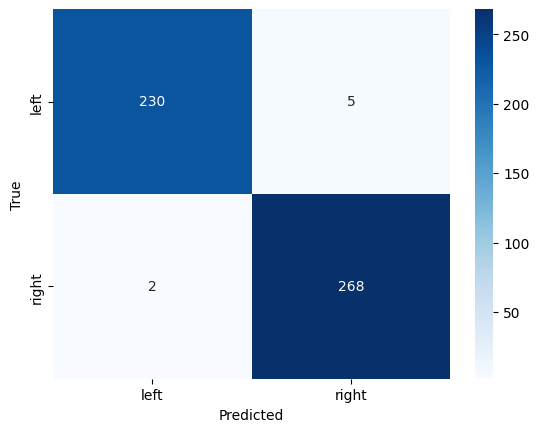

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["left", "right"],
            yticklabels=["left", "right"])

plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

## Analyse des performances

Les résultats obtenus avec le modèle TF-IDF combiné à une régression logistique montrent une performance très élevée, avec une précision proche de 99 %, traduisant une excellente capacité à distinguer les textes politiques de gauche et de droite. Cette performance s’explique en partie par la présence, dans les données OCR, de termes fortement discriminants tels que les noms de partis politiques ou certaines expressions idéologiques explicites, qui facilitent la tâche de classification. Toutefois, cette efficacité doit être interprétée avec prudence, car le modèle peut s’appuyer davantage sur la détection de mots-clés que sur une compréhension réelle du contenu sémantique des textes. Il existe ainsi un risque de biais lié à une forme de fuite d’information, dans la mesure où les éléments ayant servi à construire les labels sont également présents dans les textes. Par conséquent, des analyses complémentaires, notamment la suppression de ces indices explicites et l’utilisation de modèles plus avancés, sont nécessaires afin d’évaluer la robustesse et la capacité de généralisation du modèle.

In [18]:
feature_names = vectorizer.get_feature_names_out()
coefs = model.coef_[0]

df_coef = pd.DataFrame({
    "word": feature_names,
    "coef": coefs
})


top_right = df_coef.sort_values(by="coef", ascending=False).head(20)


top_left = df_coef.sort_values(by="coef", ascending=True).head(20)

print("=== TOP MOTS DROITE ===")
print(top_right)

print("\n=== TOP MOTS GAUCHE ===")
print(top_left)

=== TOP MOTS DROITE ===
                    word      coef
18455              union  3.266406
8119              france  2.599260
18380                udf  2.145356
15710                rpr  1.887780
18460       union france  1.774196
9285         immigration  1.731485
12341         opposition  1.710551
4216           confiance  1.338910
15018       redressement  1.252822
11827           national  1.252257
14487          président  1.195994
15723            rpr udf  1.098989
12167  nouvelle majorité  1.014557
7543             famille  1.009005
8876             général  0.992685
2763      candidat union  0.978084
15010           redonner  0.958886
7108                etat  0.952516
3303             charges  0.943969
3746                 cni  0.903422

=== TOP MOTS GAUCHE ===
                      word      coef
12662                parti -2.900813
14174              progrès -2.728264
5717                droite -2.523888
8539                gauche -2.440894
4014            communiste -2.4

L’analyse des coefficients du modèle met en évidence que les termes les plus discriminants correspondent en grande partie aux noms de partis politiques tels que « RPR », « UDF », « Parti socialiste » ou « Parti communiste ». Cela indique que le modèle s’appuie fortement sur des indices explicites présents dans les textes pour effectuer la classification. Par ailleurs, certains mots reflètent également des thématiques idéologiques pertinentes, comme « immigration » ou « national » pour la droite, et « travailleurs » ou « solidarité » pour la gauche, ce qui suggère que le modèle capte partiellement des éléments de contenu politique. Toutefois, la forte présence de noms de partis parmi les variables les plus influentes montre que la performance élevée du modèle repose en partie sur une détection de mots-clés plutôt que sur une compréhension approfondie du discours. Cette observation souligne la nécessité de mener des expérimentations complémentaires afin d’évaluer la robustesse du modèle face à des textes moins explicitement marqués politiquement.

In [19]:
import re

def remove_party_names(text):
    if pd.isna(text):
        return ""

    text = text.lower()

    parties = [
        "parti socialiste",
        "parti communiste",
        "parti communiste français",
        "front national",
        "rassemblement pour la république",
        "union pour la démocratie française",
        "rpr",
        "udf",
        "cni"
    ]

    for p in parties:
        text = re.sub(r"\b" + re.escape(p) + r"\b", "", text)

    return text

In [21]:
df["text_no_party"] = df["text"].apply(remove_party_names)
df[["text", "text_no_party"]].head(3)

,text,text_no_party
0,elections legislatives de mars 93 front nation...,elections legislatives de mars 93 les françai...
1,sciences po / fonds cevipof république françai...,sciences po / fonds cevipof république françai...
2,sciences po / fonds cevipof elections législat...,sciences po / fonds cevipof elections législat...


In [23]:
X = df["text_no_party"]
y = df["label"]


X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [24]:
vectorizer = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1, 2)
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

In [25]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train_tfidf, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [27]:
y_pred = model.predict(X_test_tfidf)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

        left       0.99      0.98      0.99       235
       right       0.98      0.99      0.99       270

    accuracy                           0.99       505
   macro avg       0.99      0.99      0.99       505
weighted avg       0.99      0.99      0.99       505



Les résultats obtenus après suppression des noms de partis politiques montrent que la performance du modèle reste quasiment inchangée, avec une précision proche de 99 %. Cela indique que le modèle ne repose pas uniquement sur la détection de mots-clés explicites, mais qu’il capture effectivement des caractéristiques linguistiques et thématiques propres aux discours politiques de gauche et de droite. En particulier, les textes de gauche sont associés à un vocabulaire centré sur la solidarité, les travailleurs et le progrès social, tandis que ceux de droite mobilisent davantage des notions liées à la nation, à l’immigration et à l’économie. Toutefois, cette performance élevée peut également s’expliquer par le caractère fortement structuré et idéologiquement marqué du corpus, ce qui facilite la tâche de classification. Ces résultats suggèrent néanmoins que le modèle parvient à saisir des éléments de contenu politique au-delà des simples affiliations partisanes

In [28]:
feature_names = vectorizer.get_feature_names_out()
coefs = model.coef_[0]

df_coef = pd.DataFrame({
    "word": feature_names,
    "coef": coefs
})


top_right = df_coef.sort_values(by="coef", ascending=False).head(20)


top_left = df_coef.sort_values(by="coef", ascending=True).head(20)

print("=== TOP MOTS DROITE ===")
print(top_right)

print("\n=== TOP MOTS GAUCHE ===")
print(top_left)

=== TOP MOTS DROITE ===
                    word      coef
18670              union  2.875440
8299              france  2.354305
10044          la france  2.298597
18677         union pour  1.778624
9222         immigration  1.693974
13069         opposition  1.526308
12679              notre  1.474905
4530       de opposition  1.180782
3531           confiance  1.176660
15587       redressement  1.127617
14991          président  1.039126
4732            de union  0.999694
12361           national  0.934945
8812             général  0.904152
8379            français  0.901319
12860  nouvelle majorité  0.889109
7864             famille  0.878920
2878             charges  0.865510
12707         notre pays  0.846759
1778        aux français  0.846046

=== TOP MOTS GAUCHE ===
                   word      coef
10002         la droite -2.578926
14747           progrès -2.394454
5641             droite -2.186702
8576             gauche -2.097764
10650               les -1.644380
19182       

L’analyse des coefficients du modèle met en évidence une séparation nette entre les champs lexicaux associés aux orientations politiques. Les textes classés à droite mobilisent principalement un vocabulaire centré sur la nation, l’ordre institutionnel et les enjeux économiques, avec des termes comme “France”, “union”, “immigration” ou “charges”. À l’inverse, les textes de gauche se caractérisent par un lexique davantage orienté vers les questions sociales et collectives, incluant des mots tels que “travailleurs”, “progrès”, “citoyens” et “mouvement”. Toutefois, la présence de termes explicitement liés aux étiquettes politiques comme “gauche” ou “droite” indique une légère fuite d’information, qui peut artificiellement renforcer la performance du modèle. Malgré cela, les résultats suggèrent que le modèle capture effectivement des différences sémantiques profondes entre les deux types de discours

In [36]:
from sklearn.feature_extraction import text
stop_words = list(text.ENGLISH_STOP_WORDS)


custom_words = [
    "gauche", "droite",
    "la gauche", "la droite",
    "gauche", "droite",
    "les", "des", "le", "la", "de" 
]

stop_words = stop_words + custom_words + french_stopwords

vectorizer = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1, 2),
    stop_words=stop_words
)

In [37]:
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

In [38]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train_tfidf, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [39]:
y_pred = model.predict(X_test_tfidf)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

        left       0.99      0.98      0.99       235
       right       0.99      0.99      0.99       270

    accuracy                           0.99       505
   macro avg       0.99      0.99      0.99       505
weighted avg       0.99      0.99      0.99       505



In [35]:
feature_names = vectorizer.get_feature_names_out()
coefs = model.coef_[0]

df_coef = pd.DataFrame({
    "word": feature_names,
    "coef": coefs
})

# Top mots droite
top_right = df_coef.sort_values(by="coef", ascending=False).head(20)

# Top mots gauche
top_left = df_coef.sort_values(by="coef", ascending=True).head(20)

print("=== TOP MOTS DROITE ===")
print(top_right)

print("\n=== TOP MOTS GAUCHE ===")
print(top_left)

=== TOP MOTS DROITE ===
                    word      coef
18544              union  3.182506
8289              france  2.590114
18551         union pour  1.946942
9278         immigration  1.803029
13691        pour france  1.788333
12281         opposition  1.746950
11890              notre  1.669277
3873           confiance  1.327263
15234       redressement  1.250759
14512          président  1.156722
11539           national  1.049291
8825             général  1.025153
7825             famille  1.015988
2614      candidat union  0.994464
12089  nouvelle majorité  0.979835
7467                etat  0.950972
11922         notre pays  0.948704
3136             charges  0.935700
15227           redonner  0.914737
9603          insécurité  0.896691

=== TOP MOTS GAUCHE ===
                    word      coef
14253            progrès -2.700140
19096               vote -1.802107
1012   alliance français -1.552843
13763       pour progrès -1.400713
11364          mouvement -1.358088
3710  

Après suppression des termes explicitement liés aux orientations politiques, l’analyse des coefficients du modèle révèle une structuration claire des discours selon des champs lexicaux distincts. Les textes classés à droite mobilisent principalement un vocabulaire centré sur la nation, la sécurité et les enjeux économiques, avec des termes tels que “France”, “immigration”, “insécurité”, “charges” ou encore “président”. À l’inverse, les textes de gauche se caractérisent par un lexique orienté vers les questions sociales et collectives, incluant des mots comme “progrès”, “solidarité”, “travailleurs” et “citoyens”. Ces résultats montrent que le modèle capture des différences sémantiques profondes entre les discours politiques, indépendamment des indices explicites tels que les noms de partis ou les étiquettes idéologiques. Cela renforce la validité de l’approche et suggère que le modèle apprend des représentations pertinentes du contenu politique.